# import file

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score, precision_score, recall_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# docfile

In [21]:
#doc file

app_df    = pd.read_csv('dataset/application_record.csv')
credit_df = pd.read_csv('dataset/credit_record.csv')

print(f"application_record : {app_df.shape}")
print(f"credit_record      : {credit_df.shape}")
print()
# print(app_df.head())
# print()
# print(credit_df['STATUS'].value_counts())
app_df.head()


application_record : (438557, 18)
credit_record      : (1048575, 3)



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1


# Tạo bien target nè

In [33]:
#tạo bien target nè

def create_target(df):
    df = df.copy()
    df['BAD'] = df['STATUS'].apply(lambda x: 1 if str(x) in ['1','2','3','4','5'] else 0) #0 xấu
    return df.groupby('ID')['BAD'].max().reset_index().rename(columns={'BAD': 'TARGET'})

user_target = create_target(credit_df)
print(f"Số khách hàng: {len(user_target):,}")
print(f"\nPhân phối TARGET:")
print(user_target['TARGET'].value_counts())
print(f"\nTỷ lệ BAD: {user_target['TARGET'].mean():.2%}")


Số khách hàng: 45,985

Phân phối TARGET:
TARGET
0    40635
1     5350
Name: count, dtype: int64

Tỷ lệ BAD: 11.63%


In [34]:

#làm sạch nè

df = app_df.merge(user_target, on='ID', how='inner')
print(f"Sau merge: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)
df.drop('ID', axis=1, inplace=True)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int) # Đổi days birth thành tuổi cho dễ đọc

print(f"\n✓ Sau xử lý: {df.shape}")

Sau merge: (36457, 19)

Missing Values:
OCCUPATION_TYPE    11323
dtype: int64

✓ Sau xử lý: (36457, 19)


In [ ]:
# eda tổng quan

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].bar(['Good (0)', 'Bad (1)'],
              df['TARGET'].value_counts().sort_index(),
              color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Target Distribution')
axes[0,0].set_ylabel('Count')

for t, c in [(0, '#2ecc71'), (1, '#e74c3c')]:
    df[df['TARGET']==t]['AGE_YEARS'].hist(ax=axes[0,1], alpha=0.7,
        label=f'{"Good" if t==0 else "Bad"}', bins=30, color=c)
axes[0,1].set_title('Age Distribution by Target')
axes[0,1].legend()

df['AMT_INCOME_TOTAL'].clip(0, 500000).hist(ax=axes[0,2], bins=50, color='steelblue')
axes[0,2].set_title('Income Distribution')

gender_ct = pd.crosstab(df['CODE_GENDER'], df['TARGET'], normalize='index') * 100
gender_ct.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Bad Rate by Gender (%)')
axes[1,0].tick_params(axis='x', rotation=0)

income_ct = pd.crosstab(df['NAME_INCOME_TYPE'], df['TARGET'], normalize='index') * 100
income_ct[1].sort_values().plot(kind='barh', ax=axes[1,1], color='#e74c3c')
axes[1,1].set_title('Bad Rate by Income Type')

edu_ct = pd.crosstab(df['NAME_EDUCATION_TYPE'], df['TARGET'], normalize='index') * 100
edu_ct[1].sort_values().plot(kind='barh', ax=axes[1,2], color='#3498db')
axes[1,2].set_title('Bad Rate by Education')

plt.suptitle('EDA - Credit Card Approval Prediction', fontsize=16)

plt.tight_layout()
plt.show()


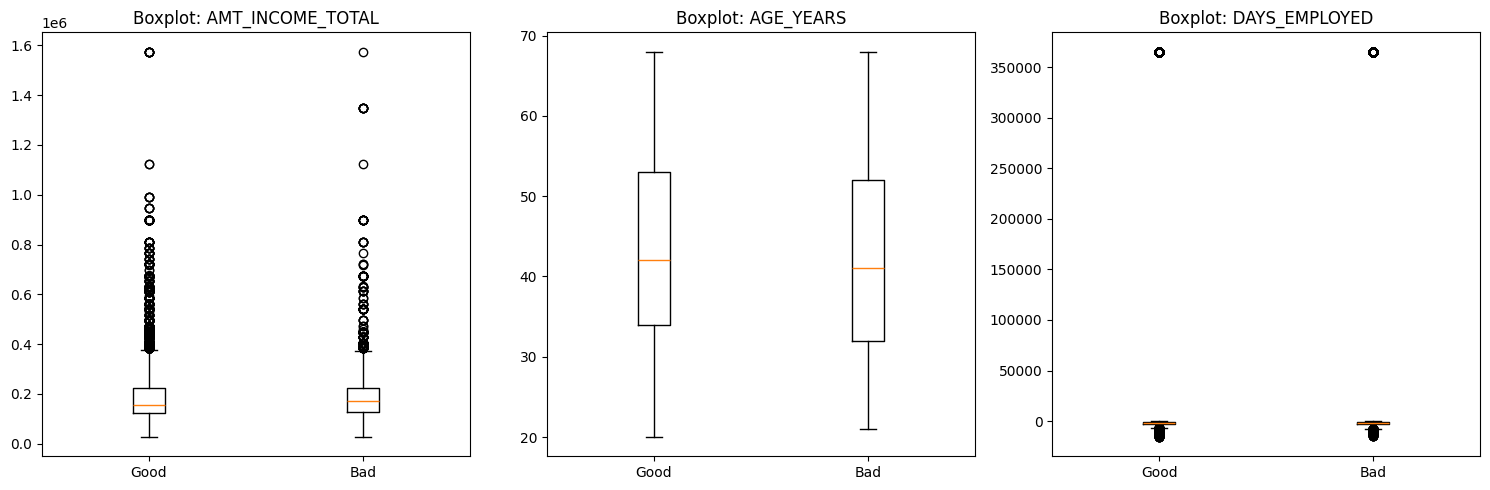

✓ Features: (36457, 47)


In [ ]:
#eda tiếp nè, phân tích outlier

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['AMT_INCOME_TOTAL', 'AGE_YEARS', 'DAYS_EMPLOYED']):
    good = df[df['TARGET']==0][col]
    bad  = df[df['TARGET']==1][col]
    axes[i].boxplot([good, bad], labels=['Good', 'Bad'])
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


#chạy feature engineer
df_fe = df.copy()

df_fe['YEARS_EMPLOYED']    = np.where(df_fe['DAYS_EMPLOYED'] > 0, 0,
                                       -df_fe['DAYS_EMPLOYED'] / 365)
df_fe['INCOME_PER_PERSON'] = df_fe['AMT_INCOME_TOTAL'] / df_fe['CNT_FAM_MEMBERS'].replace(0, 1)

le = LabelEncoder()
for col in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

cat_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
df_fe = pd.get_dummies(df_fe, columns=cat_cols, drop_first=True)
df_fe.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

X = df_fe.drop('TARGET', axis=1)
y = df_fe['TARGET']

print(f"✓ Features: {X.shape}")

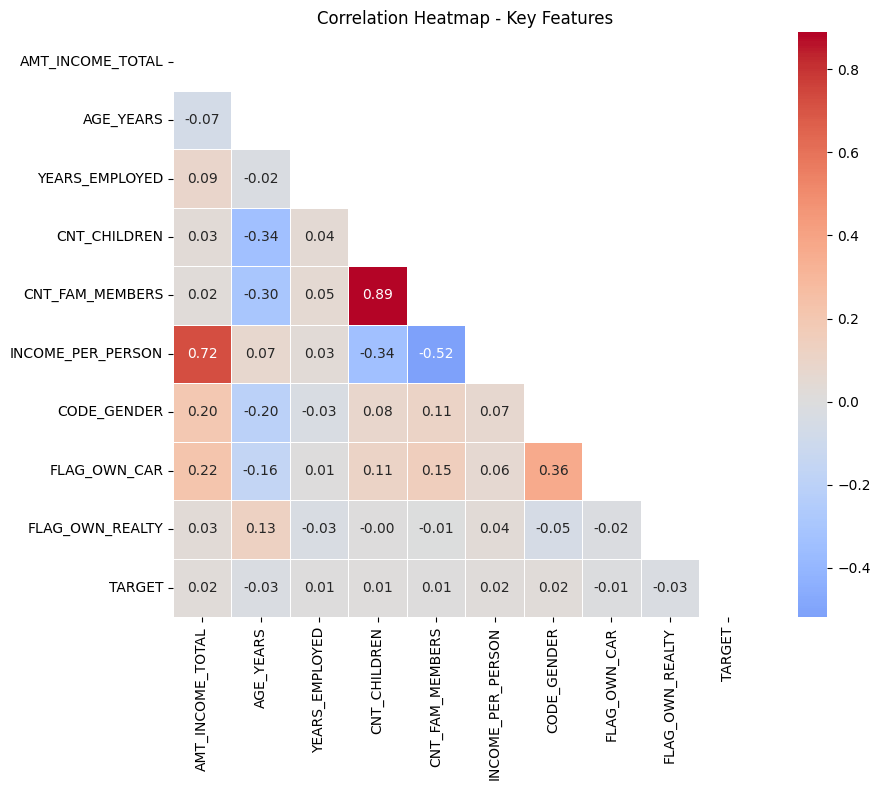

In [ ]:
# vẽ ma trận tương quan nà
key_cols = ['AMT_INCOME_TOTAL', 'AGE_YEARS', 'YEARS_EMPLOYED',
            'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'INCOME_PER_PERSON',
            'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'TARGET']

corr = df_fe[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Key Features')
plt.tight_layout()
plt.show()

In [ ]:
#train test

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train Bad Rate: {y_train.mean():.2%}")
print(f"Test  Bad Rate: {y_test.mean():.2%}")

Train: (25519, 47) | Test: (10938, 47)
Train Bad Rate: 11.77%
Test  Bad Rate: 11.77%


In [ ]:
#huấn luyện mô hình nè

models = {}
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

configs = [
    ('LR',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('RF',   RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('ET',   ExtraTreesClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('GB',   GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)),
    ('XGB',  xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                scale_pos_weight=scale_pos, random_state=42, verbosity=0, eval_metric='logloss')),
    ('LGBM', lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                  class_weight='balanced', random_state=42, verbose=-1)),
    ('MLP',  MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)),
]

for name, model in configs:
    print(f"Training {name}...", end=' ')
    model.fit(X_train, y_train)
    models[name] = model
    print("✓")

print("\n✅ Xong!")

Training LR... ✓
Training RF... ✓
Training ET... ✓
Training GB... ✓
Training XGB... ✓
Training LGBM... ✓
Training MLP... ✓

✅ Xong!


In [ ]:


#so sánh mô hình nè

results = []
for name, model in models.items():
    yp    = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:, 1]
    results.append({'Model': name,
                    'Accuracy' : round(accuracy_score(y_test, yp), 4),
                    'Precision': round(precision_score(y_test, yp), 4),
                    'Recall'   : round(recall_score(y_test, yp), 4),
                    'F1-Score' : round(f1_score(y_test, yp), 4),
                    'ROC-AUC'  : round(roc_auc_score(y_test, yprob), 4)})

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison.csv', index=False)



Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  MLP    0.8770     0.4562  0.2347    0.3099   0.7201
   RF    0.7789     0.2376  0.3978    0.2975   0.6748
 LGBM    0.6829     0.1842  0.4942    0.2684   0.6559
   ET    0.7158     0.1975  0.4623    0.2768   0.6496
  XGB    0.6750     0.1809  0.4996    0.2656   0.6442
   GB    0.8827     0.5323  0.0256    0.0489   0.6348
   LR    0.5803     0.1380  0.4895    0.2153   0.5532


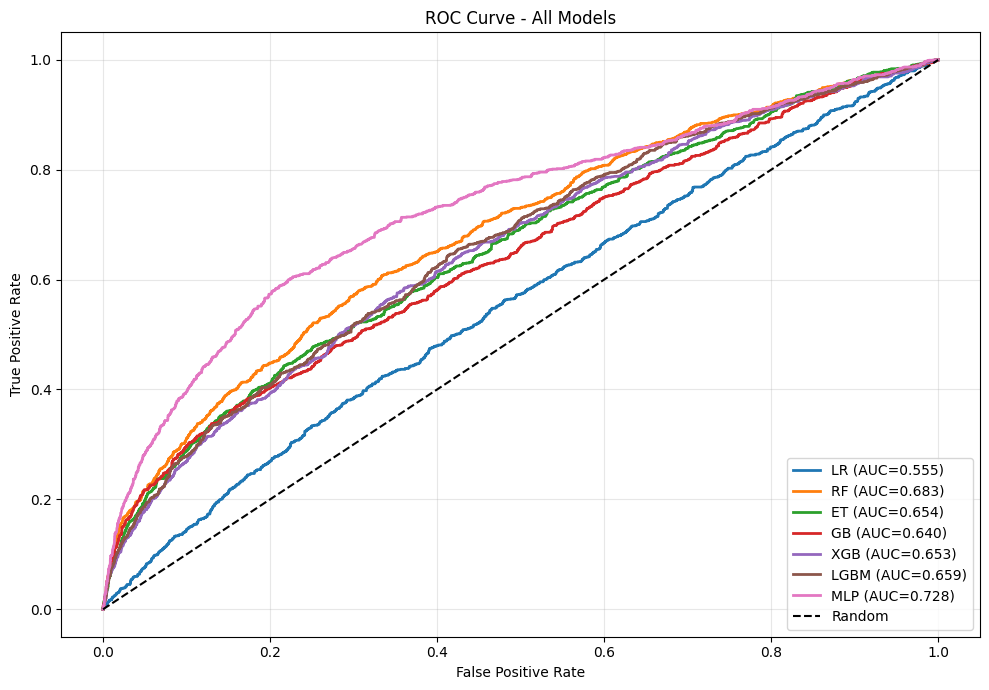

In [ ]:
#vẽ ROC nè
plt.figure(figsize=(10, 7))
for name, model in models.items():
    yprob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

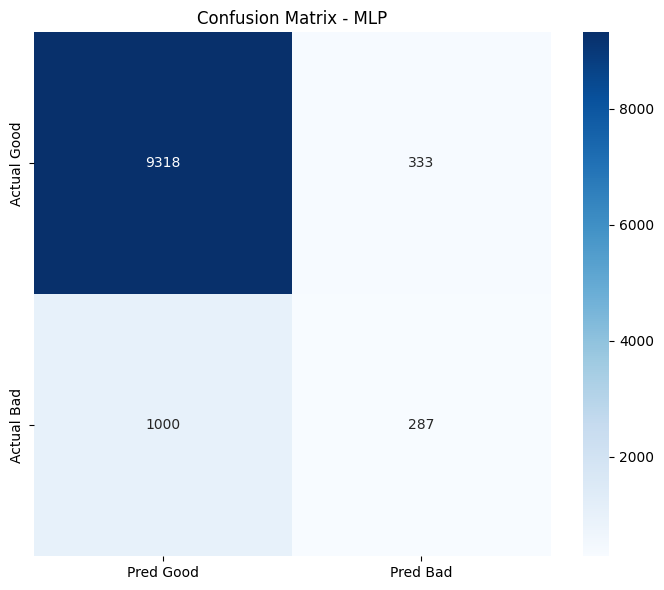

              precision    recall  f1-score   support

        Good       0.90      0.97      0.93      9651
         Bad       0.46      0.22      0.30      1287

    accuracy                           0.88     10938
   macro avg       0.68      0.59      0.62     10938
weighted avg       0.85      0.88      0.86     10938

TP=287 | FN=1000 | TN=9318 | FP=333


In [ ]:
# vẽ ma trận lấy mô hình ổn nhất nhé
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
yp_best    = best_model.predict(X_test)

cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Good', 'Pred Bad'],
            yticklabels=['Actual Good', 'Actual Bad'])
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, yp_best, target_names=['Good', 'Bad']))
tn, fp, fn, tp = cm.ravel()
print(f"TP={tp} | FN={fn} | TN={tn} | FP={fp}")

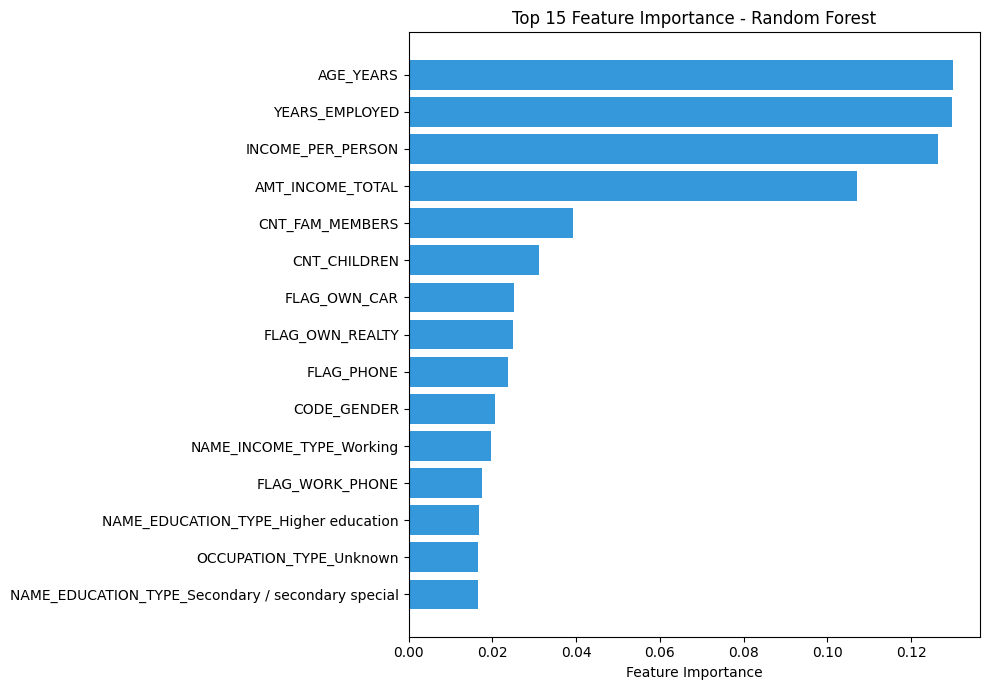

          Feature  Importance
        AGE_YEARS    0.129959
   YEARS_EMPLOYED    0.129676
INCOME_PER_PERSON    0.126363
 AMT_INCOME_TOTAL    0.107148
  CNT_FAM_MEMBERS    0.039226
     CNT_CHILDREN    0.031208
     FLAG_OWN_CAR    0.025210
  FLAG_OWN_REALTY    0.025028
       FLAG_PHONE    0.023608
      CODE_GENDER    0.020536


In [ ]:
# Dùng RF thay vì best_model vì MLP không có feature_importances_
rf = models['RF']
feat_imp = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='#3498db')
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()
print(feat_imp.head(10).to_string(index=False))

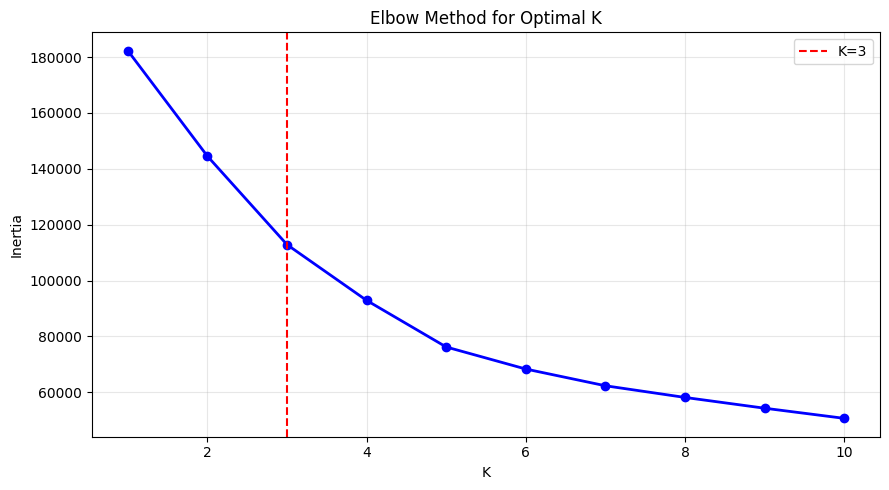

In [ ]:
# K-Means nè
cluster_feats = [c for c in ['AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL',
                              'CNT_CHILDREN', 'INCOME_PER_PERSON'] if c in df_fe.columns]
X_cluster = StandardScaler().fit_transform(df_fe[cluster_feats])

# Elbow
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inertias, 'bo-', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='K=3')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cluster 0 | MEDIUM RISK 🟡 | n=14,224 | Bad Rate=12.4%
Cluster 1 | MEDIUM RISK 🟡 | n=15,112 | Bad Rate=10.6%
Cluster 2 | MEDIUM RISK 🟡 | n=7,121 | Bad Rate=13.0%


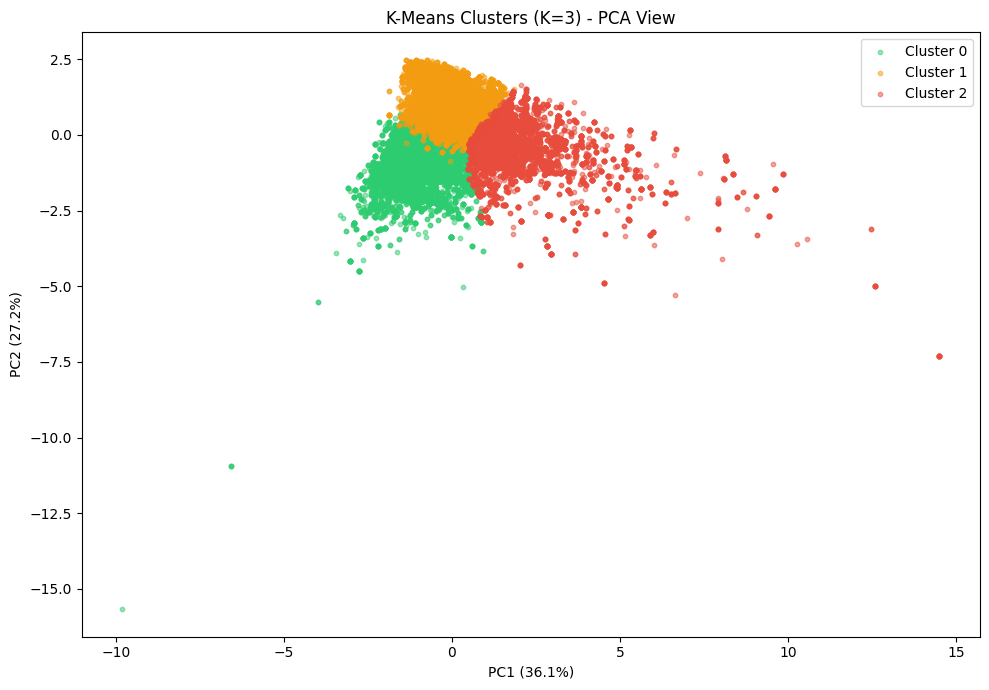

In [ ]:
#phân tích clusser nè
K = 3
kmeans   = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

df_cluster = df_fe[cluster_feats + ['TARGET']].copy()
df_cluster['Cluster'] = clusters

for c in range(K):
    sub = df_cluster[df_cluster['Cluster'] == c]
    br  = sub['TARGET'].mean()
    risk = 'HIGH RISK 🔴' if br > 0.15 else ('MEDIUM RISK 🟡' if br > 0.08 else 'LOW RISK 🟢')
    print(f"Cluster {c} | {risk} | n={len(sub):,} | Bad Rate={br:.1%}")

# PCA Visualization
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 7))
for c, col in enumerate(['#2ecc71', '#f39c12', '#e74c3c']):
    mask = clusters == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=col,
                label=f'Cluster {c}', alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means Clusters (K=3) - PCA View')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# tổng kết lại nha
print("=" * 60)
print("🎉 PIPELINE HOÀN THÀNH!")
print("=" * 60)

best = results_df.iloc[0]
print(f"\n🏆 Best Model : {best['Model']}")
print(f"   ROC-AUC    : {best['ROC-AUC']:.4f}")
print(f"   F1-Score   : {best['F1-Score']:.4f}")
print(f"   Recall     : {best['Recall']:.4f}")
print(f"\n📊 All Models:")
print(results_df.to_string(index=False))

🎉 PIPELINE HOÀN THÀNH!

🏆 Best Model : MLP
   ROC-AUC    : 0.7201
   F1-Score   : 0.3099
   Recall     : 0.2347

📊 All Models:
Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  MLP    0.8770     0.4562  0.2347    0.3099   0.7201
   RF    0.7789     0.2376  0.3978    0.2975   0.6748
 LGBM    0.6829     0.1842  0.4942    0.2684   0.6559
   ET    0.7158     0.1975  0.4623    0.2768   0.6496
  XGB    0.6750     0.1809  0.4996    0.2656   0.6442
   GB    0.8827     0.5323  0.0256    0.0489   0.6348
   LR    0.5803     0.1380  0.4895    0.2153   0.5532
